---
## Section 0 — Setup

In [1]:
!pip install SimpleITK monai tqdm scikit-learn matplotlib lungmask -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 70.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import SimpleITK as sitk
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from monai.networks.nets import DenseNet121
from monai.metrics import ROCAUCMetric
import monai.transforms as mt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Device: cuda


In [4]:
# ─── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR        = '/content/drive/MyDrive/LUNA16_Project'
ANNOTATIONS_CSV = os.path.join(BASE_DIR, 'annotations.csv')
CANDIDATES_CSV  = os.path.join(BASE_DIR, 'candidates.csv')
STAGE1_DIR      = os.path.join(BASE_DIR, 'stage1_dataset')
BEST_MODEL_PATH = os.path.join(BASE_DIR, 'best_stage1_detector.pth')
CHECKPOINT_PATH = os.path.join(BASE_DIR, 'stage1_checkpoint.pth')

# ─── Hyperparameters ─────────────────────────────────────────────────────────
PATCH_SIZE       = 64
HU_MIN           = -1000.0
HU_MAX           =  400.0
TRAIN_SPLIT      = 0.80
NEG_RATIO        = 10        # negatives = NEG_RATIO × positives per patient
BATCH_SIZE       = 16
NUM_EPOCHS       = 20
LR               = 1e-4
LR_PATIENCE      = 3
LR_FACTOR        = 0.5
EARLY_STOP       = 5

# ─── Inference settings ───────────────────────────────────────────────────────
STAGE1_THRESHOLD = 0.15      # low threshold → high sensitivity
NMS_DISTANCE     = 10        # voxels — min separation between kept candidates
STRIDE           = 16        # sliding window step
INF_BATCH        = 64        # batch size during sliding window

# ─── Positive offset strategy (8 patches per nodule) ─────────────────────────
POS_OFFSETS = [
    ( 0,  0,  0),
    (12,  0,  0), (-12,  0,  0),
    ( 0, 12,  0), (  0, -12,  0),
    ( 0,  0, 12), (  0,  0, -12),
    (random.randint(-12,12), random.randint(-12,12), random.randint(-12,12)),
]

# ─── Discover scan files ──────────────────────────────────────────────────────
mhd_files = []
for i in range(10):
    mhd_files += glob.glob(os.path.join(BASE_DIR, f'subset{i}', '*.mhd'))
    mhd_files += glob.glob(os.path.join(BASE_DIR, f'subset{i}', f'subset{i}', '*.mhd'))
    mhd_files += glob.glob(os.path.join(BASE_DIR, f'subset{i}', '**', '*.mhd'), recursive=True)
mhd_files = sorted(set(mhd_files))

df_cand  = pd.read_csv(CANDIDATES_CSV)
df_annot = pd.read_csv(ANNOTATIONS_CSV)

print(f'MHD scan files  : {len(mhd_files)}')
print(f'Candidates      : {len(df_cand):,}')
print(f'Annotations     : {len(df_annot):,}')
print(f'Saved model     : {os.path.exists(BEST_MODEL_PATH)}')
print(f'Checkpoint      : {os.path.exists(CHECKPOINT_PATH)}')

MHD scan files  : 888
Candidates      : 551,065
Annotations     : 1,186
Saved model     : True
Checkpoint      : True


---
## Section 1 — CT Preprocessing Helpers

In [5]:
def resample_scan(itk_img, new_spacing=[1.0, 1.0, 1.0]):
    """
    Resample a CT scan to isotropic 1 mm spacing using linear interpolation.
    This ensures every patch covers the same physical volume regardless of scanner.
    """
    orig_sp = np.array(itk_img.GetSpacing())
    orig_sz = np.array(itk_img.GetSize())
    new_sz  = [int(round(orig_sz[i] * (orig_sp[i] / new_spacing[i]))) for i in range(3)]

    r = sitk.ResampleImageFilter()
    r.SetOutputSpacing(new_spacing)
    r.SetSize(new_sz)
    r.SetOutputDirection(itk_img.GetDirection())
    r.SetOutputOrigin(itk_img.GetOrigin())
    r.SetTransform(sitk.Transform())
    r.SetInterpolator(sitk.sitkLinear)
    return r.Execute(itk_img)


def preprocess_scan(mhd_path):
    """
    Load a .mhd scan, resample to 1mm, clip HU to [-1000, 400], normalize to [0,1].
    Returns: (arr float32 Z×Y×X, origin mm, spacing mm)
    """
    itk_img   = sitk.ReadImage(mhd_path)
    resampled = resample_scan(itk_img)
    arr       = sitk.GetArrayFromImage(resampled).astype(np.float32)
    origin    = np.array(resampled.GetOrigin())
    spacing   = np.array(resampled.GetSpacing())
    arr       = np.clip(arr, HU_MIN, HU_MAX)
    arr       = (arr - HU_MIN) / (HU_MAX - HU_MIN)
    return arr, origin, spacing, resampled


def world_to_voxel(world_coord, origin, spacing):
    """Convert world (mm) coordinates to voxel index."""
    return np.round(np.absolute(world_coord - origin) / spacing).astype(int)


def pad_patch(patch, target=(64, 64, 64)):
    """Zero-pad a smaller-than-target patch by centering the content."""
    if patch.shape == target:
        return patch
    out = np.zeros(target, dtype=np.float32)
    z, y, x = patch.shape
    zs = (target[0]-z)//2
    ys = (target[1]-y)//2
    xs = (target[2]-x)//2
    out[zs:zs+z, ys:ys+y, xs:xs+x] = patch
    return out


def nms_3d(centers, probs, min_distance=NMS_DISTANCE):
    """
    Greedy 3-D Non-Maximum Suppression.
    Keeps only the highest-probability candidate within min_distance voxels.
    """
    if len(probs) == 0:
        return [], []
    order   = np.argsort(probs)[::-1]
    centers = np.array(centers)[order]
    probs   = np.array(probs)[order]
    kept_c, kept_p = [], []
    for i in range(len(centers)):
        if not any(np.linalg.norm(centers[i] - np.array(c)) < min_distance for c in kept_c):
            kept_c.append(centers[i])
            kept_p.append(probs[i])
    return kept_c, kept_p


def evaluate_candidates(cands, gt_coords, resampled_img):
    """
    Count TP, FP, FN by matching predicted candidates to ground-truth nodules.
    A candidate is a TP if it falls within the nodule radius of any unmatched GT.
    """
    matched = set()
    tp = 0
    for cand in cands:
        wx, wy, wz = resampled_img.TransformIndexToPhysicalPoint(
            [int(cand[2]), int(cand[1]), int(cand[0])]
        )
        for j, gt in enumerate(gt_coords):
            if j in matched:
                continue
            dist = np.linalg.norm(np.array([wx, wy, wz]) - gt['coords'])
            if dist <= gt['radius']:
                tp += 1
                matched.add(j)
                break
    fp = len(cands) - tp
    fn = len(gt_coords) - tp
    return tp, fp, fn


print('Preprocessing helpers defined.')

Preprocessing helpers defined.


---
## Section 2 — Patch Extraction

In [7]:
# Quick check — tells you whether to run extraction or skip it
if os.path.exists(STAGE1_DIR):
    counts = {}
    for sp in ('train', 'val'):
        for cl in ('positive', 'negative'):
            n = len(glob.glob(os.path.join(STAGE1_DIR, sp, cl, '*.npy')))
            counts[f'{sp}/{cl}'] = n
            print(f'  [{sp}/{cl}] : {n:,} patches')
    if all(v > 0 for v in counts.values()):
        print('\n✅ Dataset already exists. Skip to Section 3.')
    else:
        print('\n⚠️  Some folders are empty — run extraction below.')
else:
    print('❌ stage1_dataset/ not found — run extraction below.')

  [train/positive] : 8,655 patches
  [train/negative] : 17,601 patches
  [val/positive] : 1,833 patches
  [val/negative] : 4,223 patches

✅ Dataset already exists. Skip to Section 3.


In [ ]:
# ⏭ SKIP THIS CELL IF PATCHES ALREADY EXTRACTED
import shutil

REBUILD = False   # set True only to wipe and start fresh

if REBUILD and os.path.exists(STAGE1_DIR):
    shutil.rmtree(STAGE1_DIR)
    print('Old dataset deleted.')

for split in ('train', 'val'):
    for cls in ('positive', 'negative'):
        os.makedirs(os.path.join(STAGE1_DIR, split, cls), exist_ok=True)

# Patient-level 80/20 split
all_pids = sorted(df_cand['seriesuid'].unique())
random.seed(SEED)
random.shuffle(all_pids)
n_train    = int(len(all_pids) * TRAIN_SPLIT)
train_pids = set(all_pids[:n_train])
val_pids   = set(all_pids[n_train:])
print(f'Train patients: {len(train_pids)}  |  Val patients: {len(val_pids)}')

# Resumable progress log
log_path  = os.path.join(STAGE1_DIR, 'processed_log.txt')
done_pids = set()
if os.path.exists(log_path):
    with open(log_path) as f:
        done_pids = {l.strip() for l in f if l.strip()}
    print(f'Resuming — {len(done_pids)} patients already processed.')

stats = {'pos': 0, 'neg': 0, 'skipped': 0, 'errors': 0}

for mhd_path in tqdm(mhd_files, desc='Extracting patches'):
    pid = os.path.basename(mhd_path).replace('.mhd', '')
    if pid in done_pids:
        stats['skipped'] += 1
        continue
    split = 'train' if pid in train_pids else ('val' if pid in val_pids else None)
    if split is None:
        stats['skipped'] += 1
        continue
    pid_cands = df_cand[df_cand['seriesuid'] == pid]
    if pid_cands.empty:
        stats['skipped'] += 1
        continue
    try:
        arr, origin, spacing, _ = preprocess_scan(mhd_path)
        pid_pos = pid_cands[pid_cands['class'] == 1]
        pid_neg = pid_cands[pid_cands['class'] == 0]
        max_neg = max(len(pid_pos) * NEG_RATIO, 20)
        if len(pid_neg) > max_neg:
            pid_neg = pid_neg.sample(max_neg, random_state=SEED)

        for subset_df, label in [(pid_pos, 1), (pid_neg, 0)]:
            cls_dir = 'positive' if label == 1 else 'negative'
            offsets = POS_OFFSETS if label == 1 else [(0, 0, 0)]
            for idx, row in subset_df.iterrows():
                coord      = np.array([row['coordX'], row['coordY'], row['coordZ']])
                v          = world_to_voxel(coord, origin, spacing)
                vz, vy, vx = int(v[2]), int(v[1]), int(v[0])
                for oz, oy, ox in offsets:
                    z1 = (vz+oz)-32;  z2 = z1+64
                    y1 = (vy+oy)-32;  y2 = y1+64
                    x1 = (vx+ox)-32;  x2 = x1+64
                    if (z1<0 or z2>arr.shape[0] or
                        y1<0 or y2>arr.shape[1] or
                        x1<0 or x2>arr.shape[2]):
                        continue
                    patch = pad_patch(arr[z1:z2, y1:y2, x1:x2])
                    fname = f'{pid}_{idx}_off{oz}_{oy}_{ox}.npy'
                    np.save(os.path.join(STAGE1_DIR, split, cls_dir, fname), patch)
                    stats['pos' if label==1 else 'neg'] += 1

        with open(log_path, 'a') as f:
            f.write(pid + '\n')
    except Exception as e:
        print(f'  Error — {pid[:35]}: {e}')
        stats['errors'] += 1

print(f"\nPositives : {stats['pos']:,}")
print(f"Negatives : {stats['neg']:,}")
print(f"Skipped   : {stats['skipped']:,}")
print(f"Errors    : {stats['errors']:,}")

---
## Section 3 — Dataset Class & DataLoaders

In [8]:
class Stage1Dataset(Dataset):
    """
    Loads Stage-1 64³ patches from disk.
    Returns (image tensor (1,64,64,64) float32,  label tensor long)
    """
    def __init__(self, root_dir, split, transform=None):
        self.transform = transform
        pos = sorted(glob.glob(os.path.join(root_dir, split, 'positive', '*.npy')))
        neg = sorted(glob.glob(os.path.join(root_dir, split, 'negative', '*.npy')))
        self.data = (
            [{'image': f, 'label': 1} for f in pos] +
            [{'image': f, 'label': 0} for f in neg]
        )
        random.shuffle(self.data)
        print(f'[{split:5}]  pos={len(pos):,}  neg={len(neg):,}  '
              f'total={len(self.data):,}  ratio={len(neg)/max(len(pos),1):.1f}:1')

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        try:
            patch = np.load(item['image']).astype(np.float32)
            if patch.ndim == 3:
                patch = np.expand_dims(patch, 0)      # → (1, 64, 64, 64)
            sample = {'image': patch, 'label': item['label']}
            if self.transform:
                sample = self.transform(sample)
            img = sample['image']
            if hasattr(img, 'ndim') and img.ndim == 5:
                img = img.squeeze(2)                  # fix rare MONAI extra dim
            return (torch.as_tensor(img,             dtype=torch.float32),
                    torch.as_tensor(sample['label'], dtype=torch.long))
        except Exception:
            return self.__getitem__(random.randint(0, len(self.data)-1))


train_tf = mt.Compose([
    mt.RandFlipd(keys=['image'], prob=0.5, spatial_axis=0),
    mt.RandFlipd(keys=['image'], prob=0.5, spatial_axis=1),
    mt.RandFlipd(keys=['image'], prob=0.5, spatial_axis=2),
    mt.RandRotate90d(keys=['image'], prob=0.5, spatial_axes=(1, 2)),
    mt.RandGaussianNoised(keys=['image'], prob=0.2, std=0.01),
    mt.RandScaleIntensityd(keys=['image'], factors=0.1, prob=0.3),
    mt.EnsureTyped(keys=['image']),
])

train_ds = Stage1Dataset(STAGE1_DIR, 'train', transform=train_tf)
val_ds   = Stage1Dataset(STAGE1_DIR, 'val',   transform=None)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

x, y = next(iter(train_loader))
print(f'\nSanity check — image: {x.shape}  label: {y.shape}')

[train]  pos=8,655  neg=17,601  total=26,256  ratio=2.0:1
[val  ]  pos=1,833  neg=4,223  total=6,056  ratio=2.3:1

Sanity check — image: torch.Size([16, 1, 64, 64, 64])  label: torch.Size([16])


---
## Section 4 — Model + Training Loop


In [9]:
# Quick check before running training
if os.path.exists(BEST_MODEL_PATH):
    print(f'✅ Saved model found at:\n   {BEST_MODEL_PATH}')
    print('Skip to Section 5 — Evaluation.')
else:
    print('❌ No saved model found. Run the training cell below.')

✅ Saved model found at:
   /content/drive/MyDrive/LUNA16_Project/best_stage1_detector.pth
Skip to Section 5 — Evaluation.


In [ ]:
# ⏭ SKIP THIS CELL IF MODEL IS ALREADY TRAINED

# ─── Model ────────────────────────────────────────────────────────────────────
model = DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(DEVICE)

# Weighted cross-entropy — gives extra weight to the rare positive class
num_pos = max(1, sum(1 for d in train_ds.data if d['label'] == 1))
num_neg = sum(1 for d in train_ds.data if d['label'] == 0)
weight  = torch.tensor([1.0, float(num_neg) / num_pos]).to(DEVICE)
print(f'Nodule class weight: {weight[1]:.2f}x')

criterion  = nn.CrossEntropyLoss(weight=weight)
optimizer  = optim.Adam(model.parameters(), lr=LR)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=LR_PATIENCE, factor=LR_FACTOR)
auc_metric = ROCAUCMetric()

# ─── Resume from checkpoint if available ─────────────────────────────────────
best_auc = -1.0
start_epoch = 0
early_stop_counter = 0

if os.path.exists(CHECKPOINT_PATH):
    print('Checkpoint found — resuming...')
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    best_auc           = ckpt['best_auc']
    start_epoch        = ckpt['epoch'] + 1
    early_stop_counter = ckpt.get('early_stop_counter', 0)
    print(f'Resuming at epoch {start_epoch+1} | Best AUC so far: {best_auc:.4f}')
else:
    print('No checkpoint — starting from scratch.')

# ─── Training loop ────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
print(f'Training on: {DEVICE}')
print('=' * 55)

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f'\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---')

    # Train
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc='  Train', leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        if inputs.ndim == 6: inputs = inputs.squeeze(2)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    avg_train = epoch_loss / len(train_loader)
    history['train_loss'].append(avg_train)
    print(f'  Train Loss : {avg_train:.4f}')

    # Validate
    model.eval()
    val_loss = 0.0
    y_pred, y_true = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='  Val', leave=False):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            if inputs.ndim == 6: inputs = inputs.squeeze(2)
            out      = model(inputs)
            val_loss += criterion(out, labels).item()
            y_pred.append(torch.softmax(out, dim=1)[:, 1])
            y_true.append(labels)

    y_pred     = torch.cat(y_pred)
    y_true     = torch.cat(y_true)
    auc_metric(y_pred=y_pred, y=y_true)
    auc_score  = float(auc_metric.aggregate())
    auc_metric.reset()
    avg_val    = val_loss / len(val_loader)
    history['val_loss'].append(avg_val)
    history['val_auc'].append(auc_score)
    scheduler.step(avg_val)
    print(f'  Val Loss   : {avg_val:.4f}  |  Val AUC : {auc_score:.4f}')

    # Save best
    if auc_score > best_auc:
        best_auc = auc_score
        early_stop_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  ★ New best AUC: {best_auc:.4f} — model saved.')
    else:
        early_stop_counter += 1
        print(f'  No improvement. Counter: {early_stop_counter}/{EARLY_STOP}')

    # Checkpoint every epoch
    torch.save({
        'epoch': epoch, 'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_auc': best_auc, 'early_stop_counter': early_stop_counter,
    }, CHECKPOINT_PATH)

    if early_stop_counter >= EARLY_STOP:
        print(f'\nEarly stopping triggered at epoch {epoch+1}.')
        break

print(f'\nDone. Best Val AUC: {best_auc:.4f}')
print(f'Model saved → {BEST_MODEL_PATH}')

---
## Section 5 — Patch-Level Evaluation


In [11]:
# ─── Load best saved model ────────────────────────────────────────────────────
if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(
        f'Model not found at:\n  {BEST_MODEL_PATH}\n'
        'Run Section 4 first, or check the path above.'
    )

eval_model = DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(DEVICE)
eval_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
eval_model.eval()
print(f'Model loaded from: {BEST_MODEL_PATH}')
print(f'Parameters       : {sum(p.numel() for p in eval_model.parameters()):,}')

Model loaded from: /content/drive/MyDrive/LUNA16_Project/best_stage1_detector.pth
Parameters       : 11,244,674


In [12]:
# ─── Collect predictions on entire validation set ────────────────────────────
all_probs, all_labels = [], []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc='Running inference on val set'):
        inputs = inputs.to(DEVICE)
        if inputs.ndim == 6: inputs = inputs.squeeze(2)
        probs = torch.softmax(eval_model(inputs), dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
print(f'Samples evaluated : {len(all_labels):,}')
print(f'Nodules (pos)     : {int(all_labels.sum()):,}')
print(f'Negatives         : {int((all_labels==0).sum()):,}')

Running inference on val set:   0%|          | 0/379 [00:00<?, ?it/s]

Samples evaluated : 6,056
Nodules (pos)     : 1,833
Negatives         : 4,223


In [13]:
 # ─── Compute metrics ─────────────────────────────────────────────────────────
auc       = roc_auc_score(all_labels, all_probs)
preds     = (all_probs >= STAGE1_THRESHOLD).astype(int)
cm        = confusion_matrix(all_labels, preds)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / max(tp + fn, 1)
specificity = tn / max(tn + fp, 1)
fpr_arr, tpr_arr, _ = roc_curve(all_labels, all_probs)
print(f'ROC-AUC : {auc:.4f}')
print(f'\nClassification report  (threshold = {STAGE1_THRESHOLD}):')
print(classification_report(all_labels, preds, target_names=['Negative', 'Nodule']))

ROC-AUC : 0.9735

Classification report  (threshold = 0.15):
              precision    recall  f1-score   support

    Negative       0.97      0.85      0.91      4223
      Nodule       0.73      0.95      0.82      1833

    accuracy                           0.88      6056
   macro avg       0.85      0.90      0.86      6056
weighted avg       0.90      0.88      0.88      6056



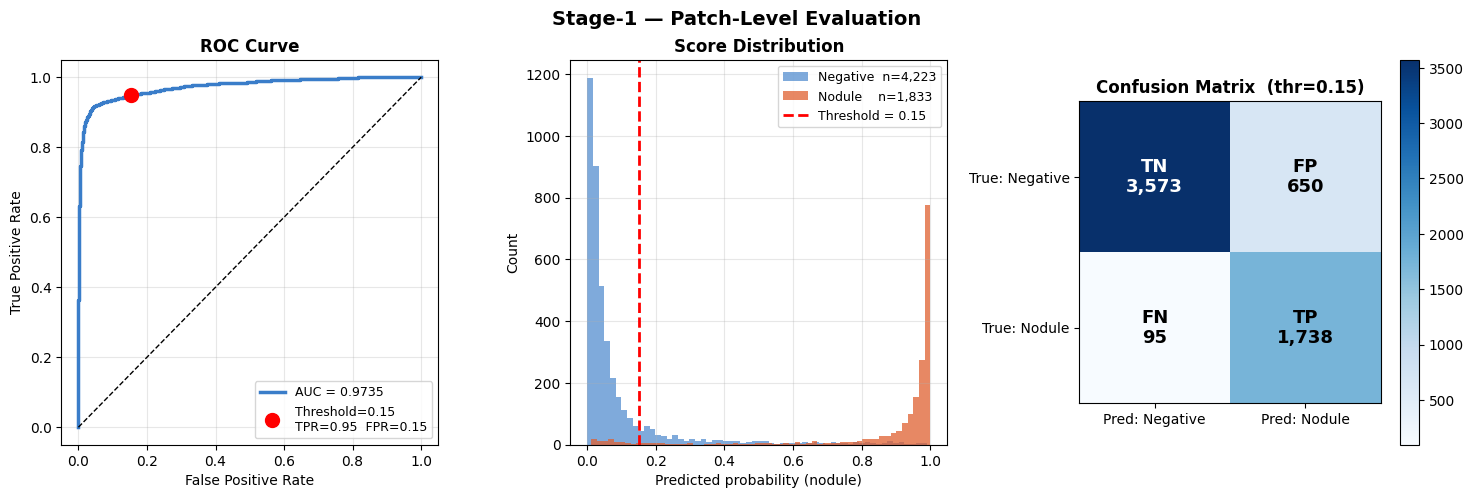

Saved → stage1_patch_eval.png


In [14]:
fig = plt.figure(figsize=(18, 5))
fig.suptitle('Stage-1 — Patch-Level Evaluation', fontsize=14, fontweight='bold')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── ROC Curve ────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(fpr_arr, tpr_arr, color='#3A7DC9', lw=2.5, label=f'AUC = {auc:.4f}')
ax1.plot([0,1], [0,1], 'k--', lw=1)
# Mark the operating point at chosen threshold
from sklearn.metrics import roc_curve as _rc
_, _, thrs = _rc(all_labels, all_probs)
idx_thr = np.argmin(np.abs(thrs - STAGE1_THRESHOLD))
ax1.plot(fpr_arr[idx_thr], tpr_arr[idx_thr], 'ro', markersize=10, zorder=5,
         label=f'Threshold={STAGE1_THRESHOLD}\nTPR={tpr_arr[idx_thr]:.2f}  FPR={fpr_arr[idx_thr]:.2f}')
ax1.set_xlabel('False Positive Rate');  ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', fontweight='bold')
ax1.legend(fontsize=9);  ax1.grid(alpha=0.3)

# ── Score Distribution ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.hist(all_probs[all_labels==0], bins=60, alpha=0.65,
         color='#3A7DC9', label=f'Negative  n={int((all_labels==0).sum()):,}')
ax2.hist(all_probs[all_labels==1], bins=60, alpha=0.75,
         color='#E06030', label=f'Nodule    n={int(all_labels.sum()):,}')
ax2.axvline(STAGE1_THRESHOLD, color='red', linestyle='--', lw=2,
            label=f'Threshold = {STAGE1_THRESHOLD}')
ax2.set_xlabel('Predicted probability (nodule)');  ax2.set_ylabel('Count')
ax2.set_title('Score Distribution', fontweight='bold')
ax2.legend(fontsize=9);  ax2.grid(alpha=0.3)

# ── Confusion Matrix ─────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
cm_vals = np.array([[tn, fp], [fn, tp]])
im = ax3.imshow(cm_vals, cmap='Blues')
labels_cm = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        col = 'white' if cm_vals[i,j] > cm_vals.max()*0.55 else 'black'
        ax3.text(j, i, f'{labels_cm[i][j]}\n{cm_vals[i,j]:,}',
                 ha='center', va='center', fontsize=13, fontweight='bold', color=col)
ax3.set_xticks([0,1]); ax3.set_xticklabels(['Pred: Negative', 'Pred: Nodule'])
ax3.set_yticks([0,1]); ax3.set_yticklabels(['True: Negative', 'True: Nodule'])
ax3.set_title(f'Confusion Matrix  (thr={STAGE1_THRESHOLD})', fontweight='bold')
plt.colorbar(im, ax=ax3)

plt.savefig('stage1_patch_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → stage1_patch_eval.png')

In [ ]:
print('=' * 58)
print('  STAGE-1 — PATCH-LEVEL RESULTS')
print('=' * 58)
print(f'  ROC-AUC             : {auc:.4f}')
print(f'  Threshold           : {STAGE1_THRESHOLD}')
print(f'  Sensitivity (TPR)   : {sensitivity*100:.2f}%')
print(f'  Specificity (TNR)   : {specificity*100:.2f}%')
print(f'  True  Positives     : {tp:,}')
print(f'  False Positives     : {fp:,}')
print(f'  False Negatives     : {fn:,}  ← missed nodules')
print(f'  True  Negatives     : {tn:,}')
print('=' * 58)

  STAGE-1 — PATCH-LEVEL RESULTS
  ROC-AUC             : 0.9735
  Threshold           : 0.15
  Sensitivity (TPR)   : 94.82%
  Specificity (TNR)   : 84.61%
  True  Positives     : 1,738
  False Positives     : 650
  False Negatives     : 95  ← missed nodules
  True  Negatives     : 3,573


---
## Section 6 — Scan-Level Evaluation

In [6]:
from lungmask import mask as lungmask_model

# Use the same eval_model already loaded in Section 5
# (re-runs the load if this section is run standalone)
if 'eval_model' not in dir() or eval_model is None:
    eval_model = DenseNet121(spatial_dims=3, in_channels=1, out_channels=2).to(DEVICE)
    eval_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
    eval_model.eval()
    print(f'Model loaded from: {BEST_MODEL_PATH}')

# Build list of all patients that have annotations AND MHD files in Drive
available_pids  = {os.path.basename(f).replace('.mhd', ''): f for f in mhd_files}
annotated_pids  = df_annot['seriesuid'].unique().tolist()
eval_pids       = [p for p in annotated_pids if p in available_pids]

print(f'Annotated patients available for scan-level eval: {len(eval_pids)}')

if len(eval_pids) == 0:
    print('No matching patients found. Check BASE_DIR and subset folder structure.')

Model loaded from: /content/drive/MyDrive/LUNA16_Project/best_stage1_detector.pth
Annotated patients available for scan-level eval: 601


In [ ]:
import gc
import ctypes

CHECKPOINT_CSV = '/content/drive/MyDrive/LUNA16_Project/stage1_eval_checkpoint.csv'

# ── Resume from checkpoint if it exists ──────────────────────────────────────
if os.path.exists(CHECKPOINT_CSV):
    df_ckpt          = pd.read_csv(CHECKPOINT_CSV)
    per_scan_results = df_ckpt.to_dict('records')
    done_pids        = set(df_ckpt['patient'].tolist())
    total_tp  = int(df_ckpt['tp'].sum())
    total_fp  = int(df_ckpt['fp'].sum())
    total_fn  = int(df_ckpt['fn'].sum())
    total_gt  = int(df_ckpt['gt'].sum())
    print(f'Resumed: {len(done_pids)} scans already done.')
else:
    per_scan_results = []
    done_pids        = set()
    total_tp = total_fp = total_fn = total_gt = 0
    print('Starting fresh.')

for idx, pid in enumerate(eval_pids):
    if pid in done_pids:
        continue

    mhd_path = available_pids[pid]
    print(f'[{idx+1}/{len(eval_pids)}] {pid[:50]}', end=' ... ')

    try:
        # ── Preprocess scan ───────────────────────────────────────────────────
        arr, _, _, resampled_img = preprocess_scan(mhd_path)
        lung_mask = (lungmask_model.apply(resampled_img) > 0).astype(np.uint8)

        # ── Ground-truth nodules for this patient ─────────────────────────────
        gt_rows  = df_annot[df_annot['seriesuid'] == pid]
        gt_coords = [
            {
                'coords': np.array([r['coordX'], r['coordY'], r['coordZ']]),
                'radius': max(r['diameter_mm'] / 2.0, 15.0)
            }
            for _, r in gt_rows.iterrows()
        ]
        n_gt = len(gt_coords)
        total_gt += n_gt

        # ── Sliding window inference ──────────────────────────────────────────
        D, H, W = arr.shape
        s1_cands, s1_probs = [], []
        b_patches, b_coords = [], []

        with torch.no_grad():
            for z in range(0, D-PATCH_SIZE+1, STRIDE):
                for y in range(0, H-PATCH_SIZE+1, STRIDE):
                    for x in range(0, W-PATCH_SIZE+1, STRIDE):
                        block = lung_mask[z:z+PATCH_SIZE, y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                        if block.sum() < 0.3 * PATCH_SIZE**3:
                            continue
                        patch = arr[z:z+PATCH_SIZE, y:y+PATCH_SIZE, x:x+PATCH_SIZE]
                        if patch.shape != (PATCH_SIZE, PATCH_SIZE, PATCH_SIZE):
                            continue
                        b_patches.append(patch)
                        b_coords.append([z+PATCH_SIZE//2, y+PATCH_SIZE//2, x+PATCH_SIZE//2])

                        if len(b_patches) == INF_BATCH:
                            t = torch.tensor(np.array(b_patches),
                                             dtype=torch.float32).unsqueeze(1).to(DEVICE)
                            pv = torch.softmax(eval_model(t), dim=1)[:,1].cpu().numpy()
                            for k, p in enumerate(pv):
                                if p >= STAGE1_THRESHOLD:
                                    s1_cands.append(b_coords[k])
                                    s1_probs.append(float(p))
                            b_patches, b_coords = [], []

            # Flush remaining batch
            if b_patches:
                t = torch.tensor(np.array(b_patches),
                                 dtype=torch.float32).unsqueeze(1).to(DEVICE)
                pv = torch.softmax(eval_model(t), dim=1)[:,1].cpu().numpy()
                for k, p in enumerate(pv):
                    if p >= STAGE1_THRESHOLD:
                        s1_cands.append(b_coords[k])
                        s1_probs.append(float(p))

        # ── FIX 1: free lung mask immediately ────────────────────────────────
        del lung_mask
        gc.collect()

        # ── NMS + Evaluate ────────────────────────────────────────────────────
        nms_cands, _ = nms_3d(s1_cands, s1_probs)
        tp, fp, fn   = evaluate_candidates(nms_cands, gt_coords, resampled_img)

        total_tp += tp
        total_fp += fp
        total_fn += fn

        per_scan_results.append({
            'patient': pid,  # full pid — no truncation
            'gt': n_gt, 'tp': tp, 'fp': fp, 'fn': fn,
            'candidates_before_nms': len(s1_cands),
            'candidates_after_nms':  len(nms_cands),
        })
        print(f'GT={n_gt}  TP={tp}  FP={fp}  FN={fn}')

        # ── FIX 2: free CT array before next scan ─────────────────────────────
        del arr, resampled_img
        gc.collect()

    except Exception as e:
        print(f'ERROR: {e}')
        continue

    # ── FIX 3: force RAM release + save checkpoint to Drive ───────────────────
    gc.collect()
    torch.cuda.empty_cache()
    ctypes.CDLL("libc.so.6").malloc_trim(0)

    pd.DataFrame(per_scan_results).to_csv(CHECKPOINT_CSV, index=False)

print(f'\nScan-level inference complete ({len(per_scan_results)} scans).')

Resumed: 7 scans already done.
[8/601] 1.3.6.1.4.1.14519.5.2.1.6279.6001.1061649783701169 ... 

102%|██████████| 17/16.6 [00:08<-00:00,  2.09it/s]

lungmask 2026-05-04 04:06:07 Postprocessing



100%|██████████| 14/14 [00:00<00:00, 39.92it/s]


GT=1  TP=1  FP=380  FN=0
[9/601] 1.3.6.1.4.1.14519.5.2.1.6279.6001.1063796589206266 ... 

...


100%|██████████| 3/3 [00:00<00:00, 30.90it/s]


GT=1  TP=1  FP=667  FN=0
[89/601] 1.3.6.1.4.1.14519.5.2.1.6279.6001.1472507070710978 ... 

101%|██████████| 15/14.8 [00:07<-00:00,  2.07it/s]

lungmask 2026-05-04 05:00:05 Postprocessing



100%|██████████| 3/3 [00:00<00:00, 332.81it/s]


In [16]:
import pandas as pd

CHECKPOINT_CSV = '/content/drive/MyDrive/LUNA16_Project/stage1_eval_checkpoint.csv'

df_ckpt          = pd.read_csv(CHECKPOINT_CSV)
per_scan_results = df_ckpt.to_dict('records')
total_tp  = int(df_ckpt['tp'].sum())
total_fp  = int(df_ckpt['fp'].sum())
total_fn  = int(df_ckpt['fn'].sum())
total_gt  = int(df_ckpt['gt'].sum())

print(f'Restored {len(df_ckpt)} scans from checkpoint.')
print(f'TP={total_tp}  FP={total_fp}  FN={total_fn}  GT={total_gt}')

Restored 90 scans from checkpoint.
TP=166  FP=53296  FN=6  GT=172


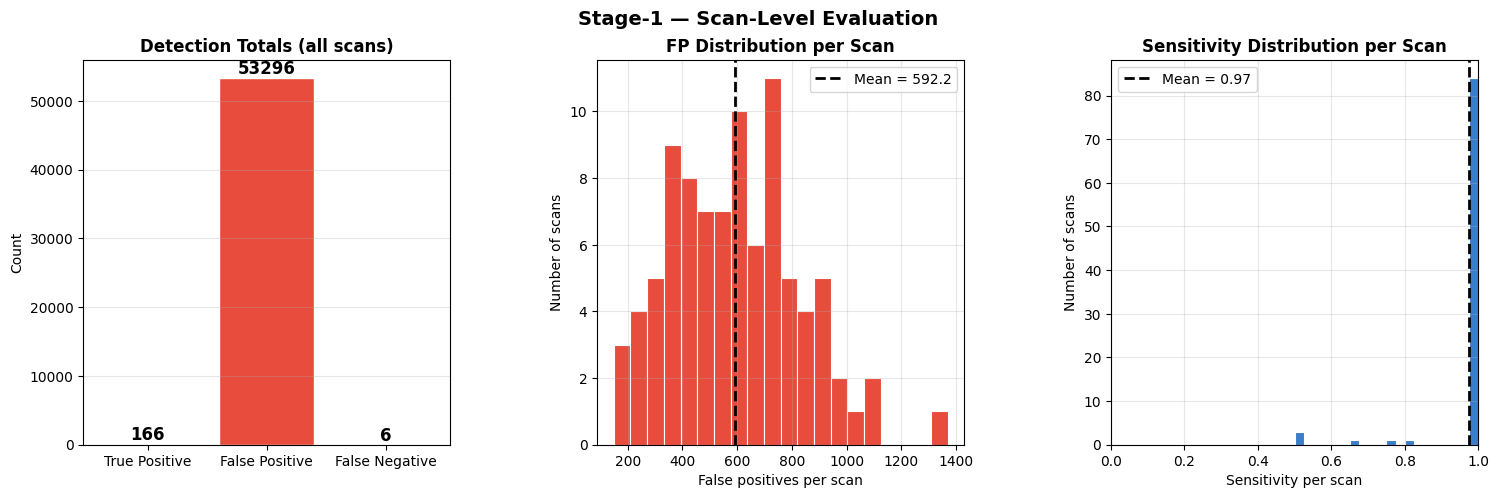

Saved → stage1_scan_eval.png


In [17]:
sensitivity = total_tp / max(total_tp + total_fn, 1)
fp_per_scan = total_fp / max(len(per_scan_results), 1)
df_results  = pd.DataFrame(per_scan_results)

fig = plt.figure(figsize=(18, 5))
fig.suptitle('Stage-1 — Scan-Level Evaluation', fontsize=14, fontweight='bold')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.40)

# ── Bar: total TP / FP / FN ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
bars = ax1.bar(['True Positive', 'False Positive', 'False Negative'],
               [total_tp, total_fp, total_fn],
               color=['#2ECC71', '#E74C3C', '#F39C12'],
               edgecolor='white', linewidth=1)
for b, v in zip(bars, [total_tp, total_fp, total_fn]):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, str(v),
             ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.set_title('Detection Totals (all scans)', fontweight='bold')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)

# ── Per-scan FP distribution ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.hist(df_results['fp'], bins=20, color='#E74C3C', edgecolor='white', linewidth=0.8)
ax2.axvline(fp_per_scan, color='black', linestyle='--', lw=2,
            label=f'Mean = {fp_per_scan:.1f}')
ax2.set_xlabel('False positives per scan')
ax2.set_ylabel('Number of scans')
ax2.set_title('FP Distribution per Scan', fontweight='bold')
ax2.legend();  ax2.grid(alpha=0.3)

# ── Per-scan sensitivity ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
per_scan_sens = df_results['tp'] / np.maximum(df_results['tp'] + df_results['fn'], 1)
ax3.hist(per_scan_sens, bins=20, color='#3A7DC9', edgecolor='white', linewidth=0.8)
ax3.axvline(per_scan_sens.mean(), color='black', linestyle='--', lw=2,
            label=f'Mean = {per_scan_sens.mean():.2f}')
ax3.set_xlabel('Sensitivity per scan')
ax3.set_ylabel('Number of scans')
ax3.set_title('Sensitivity Distribution per Scan', fontweight='bold')
ax3.set_xlim(0, 1);  ax3.legend();  ax3.grid(alpha=0.3)

plt.savefig('stage1_scan_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → stage1_scan_eval.png')

In [18]:
# ── Per-scan results table ────────────────────────────────────────────────────
df_results['sensitivity'] = (df_results['tp'] /
                              np.maximum(df_results['tp'] + df_results['fn'], 1)).round(3)
display(df_results.sort_values('fp', ascending=False).reset_index(drop=True))

,patient,gt,tp,fp,fn,candidates_before_nms,candidates_after_nms,sensitivity
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.124822907934...,5,4,1369,1,1373,1373,0.80
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.130036599816...,1,1,1086,0,1087,1087,1.00
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.126264578931...,1,1,1072,0,1073,1073,1.00
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.143622857676...,1,1,1003,0,1004,1004,1.00
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.129055977637...,1,1,997,0,998,998,1.00
...,...,...,...,...,...,...,...,...
85,1.3.6.1.4.1.14519.5.2.1.6279.6001.134996872583...,4,3,258,1,261,261,0.75
86,1.3.6.1.4.1.14519.5.2.1.6279.6001.105495028985...,1,1,254,0,255,255,1.00
87,1.3.6.1.4.1.14519.5.2.1.6279.6001.106379658920...,2,2,203,0,205,205,1.00
88,1.3.6.1.4.1.14519.5.2.1.6279.6001.127965161564...,1,1,182,0,183,183,1.00


In [19]:
# ── Final report ──────────────────────────────────────────────────────────────
print('=' * 60)
print('  STAGE-1 DETECTOR — FINAL REPORT')
print('=' * 60)
print(f'  Scans evaluated          : {len(per_scan_results)}')
print(f'  Total ground-truth nodules: {total_gt}')
print()
print(f'  True  Positives (TP)     : {total_tp}')
print(f'  False Negatives (FN)     : {total_fn}  ← missed nodules')
print(f'  False Positives (FP)     : {total_fp}  ← to be reduced by Stage-2')
print()
print(f'  SENSITIVITY              : {sensitivity*100:.2f}%')
print(f'  Avg FP per scan          : {fp_per_scan:.1f}')
print('=' * 60)
print()
print('Next step → Stage-2 False Positive Reduction notebook.')

  STAGE-1 DETECTOR — FINAL REPORT
  Scans evaluated          : 90
  Total ground-truth nodules: 172

  True  Positives (TP)     : 166
  False Negatives (FN)     : 6  ← missed nodules
  False Positives (FP)     : 53296  ← to be reduced by Stage-2

  SENSITIVITY              : 96.51%
  Avg FP per scan          : 592.2

Next step → Stage-2 False Positive Reduction notebook.
